<a href="https://colab.research.google.com/github/swanjala849-Mas/Machine-Learning/blob/main/Binary_Classification_with_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
median_progression = df['target'].median()
print(f"Median progression score: {median_progression}")
# Create a binary column 'high_risk'
# 1 if target > median_progression, else 0
df['high_risk'] = (df['target'] > median_progression).astype(int)
# Drop the old continuous target column
df = df.drop(columns=['target'])
# Verify the new class distribution
print("\nClass distribution in 'high_risk':")
print(df['high_risk'].value_counts())

Median progression score: 140.5

Class distribution in 'high_risk':
high_risk
1    221
0    221
Name: count, dtype: int64


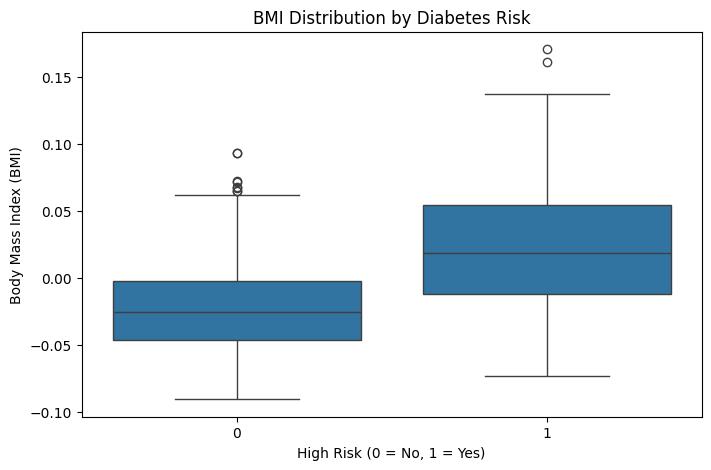

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='high_risk', y='bmi', data=df)
plt.title('BMI Distribution by Diabetes Risk')
plt.xlabel('High Risk (0 = No, 1 = Yes)')
plt.ylabel('Body Mass Index (BMI)')
plt.show()

In [5]:
# Define features (X) and target (y)
X = df.drop(columns=['high_risk'])
y = df['high_risk']
# Split the dataset: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (353, 10)
Testing features shape: (89, 10)


In [6]:
# Initialize the model
model = LogisticRegression(max_iter=1000)
# Train the model
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [7]:
# Display intercept and coefficients
print(f"Intercept (Beta 0): {model.intercept_[0]:.4f}\n")
coefficients = pd.DataFrame({
'Feature': X.columns,
'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print(coefficients)

Intercept (Beta 0): 0.0380

  Feature  Coefficient
2     bmi     2.666148
8      s5     2.440291
3      bp     2.067847
7      s4     1.531490
9      s6     1.440100
0     age     0.693373
4      s1     0.410421
5      s2     0.174499
1     sex    -0.678734
6      s3    -1.686979


In [8]:
# Generate predictions
y_pred = model.predict(X_test)

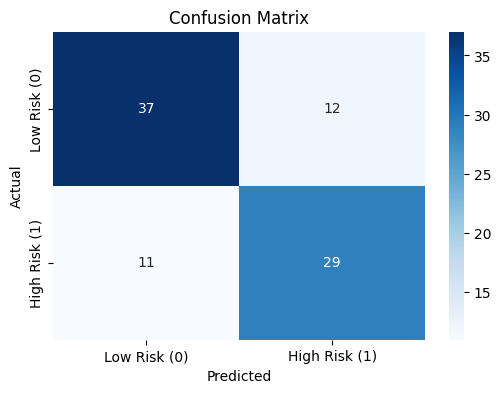

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Low Risk (0)', 'High Risk (1)'],
yticklabels=['Low Risk (0)', 'High Risk (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy:.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Overall Model Accuracy: 0.7416

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76        49
           1       0.71      0.72      0.72        40

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



In [11]:
# 1. Weak Regularization (High C)
model_weak = LogisticRegression(C=1000, max_iter=1000)
model_weak.fit(X_train, y_train)

LogisticRegression(C=1000, max_iter=1000)

In [12]:
# 2. Balanced Regularization (Default C=1.0)
model_balanced = LogisticRegression(C=1.0, max_iter=1000)
model_balanced.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
# 3. Strong Regularization (Small C)
model_strong = LogisticRegression(C=0.01, max_iter=1000)
model_strong.fit(X_train, y_train)
# Consolidate coefficients into a single DataFrame for comparison
coef_comparison = pd.DataFrame({
'Feature': X.columns,
'Weak Reg (C=1000)': model_weak.coef_[0],
'Balanced (C=1.0)': model_balanced.coef_[0],
'Strong Reg (C=0.01)': model_strong.coef_[0]
})
print(coef_comparison.round(4))

  Feature  Weak Reg (C=1000)  Balanced (C=1.0)  Strong Reg (C=0.01)
0     age             2.6943            0.6934               0.0130
1     sex           -12.6792           -0.6787              -0.0040
2     bmi            15.0729            2.6661               0.0394
3      bp            12.0795            2.0678               0.0311
4      s1            -6.2044            0.4104               0.0126
5      s2            -1.6053            0.1745               0.0096
6      s3           -11.7744           -1.6870              -0.0265
7      s4             0.7572            1.5315               0.0281
8      s5            16.9334            2.4403               0.0380
9      s6             0.1778            1.4401               0.0257


In [14]:
print(f"Test Accuracy (Weak Reg, C=1000): {accuracy_score(y_test,
model_weak.predict(X_test)):.4f}")
print(f"Test Accuracy (Balanced, C=1.0): {accuracy_score(y_test,
model_balanced.predict(X_test)):.4f}")
print(f"Test Accuracy (Strong Reg, C=0.01): {accuracy_score(y_test,
model_strong.predict(X_test)):.4f}")

Test Accuracy (Weak Reg, C=1000): 0.7191
Test Accuracy (Balanced, C=1.0): 0.7416
Test Accuracy (Strong Reg, C=0.01): 0.4494


The output shows the test accuracy for three different Logistic Regression models, each with a different regularization strength, controlled by the parameter `C`:

*   **Test Accuracy (Weak Reg, C=1000): 0.7191**
    *   A high value of `C` (like 1000) indicates *weak regularization*. This means the model is allowed to fit the training data very closely, potentially leading to overfitting. The accuracy of 0.7191 is slightly lower than the balanced model, suggesting that perhaps this model is overfitting a bit and doesn't generalize as well to unseen test data.

*   **Test Accuracy (Balanced, C=1.0): 0.7416**
    *   This is the default regularization strength (`C=1.0`). It strikes a balance between fitting the training data and keeping the model coefficients from becoming too large. This model achieves the highest accuracy among the three (0.7416), suggesting it found a good balance, generalizing well to the test data.

*   **Test Accuracy (Strong Reg, C=0.01): 0.4494**
    *   A low value of `C` (like 0.01) indicates *strong regularization*. This heavily penalizes large coefficients, forcing the model to be simpler. While this helps prevent overfitting, too strong regularization can lead to *underfitting*, where the model is too simple to capture the underlying patterns in the data. The significantly lower accuracy of 0.4494 confirms that this model is underfitting and performing poorly on the test set.

In summary, the `Balanced` model with `C=1.0` appears to be the most effective in this scenario, as it achieved the highest test accuracy, indicating the best generalization performance.